In [1]:
import collections
import random
import copy
from typing import Tuple # For Python < 3.9

from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import gymnasium as gym
import torch 
import torch.nn.functional as F

After adopting the replay buffer, there is still a problem for calculating the gradient of the loss function. If we update and utilize the policy network at the same time, the training process will be unstable. Therefore, we need to use a target network to calculate the target value. The target network is a copy of the main network, and it is updated every specific step size. The target network, with parameters $w_T$ is used to calculate the TD target. The main network, with parameters $w$ is used to calculate the current value. Hence, the training process is as follows:

\begin{equation}
w \gets w - \alpha_t \left(r_{t+1}+\gamma \max_{a^{\prime} \in \mathcal{A}(s_{t+1})} \hat{q}\left(s_{t+1}, a^{\prime}, w_{T}\right)-\hat{q}(s_t, a_t, w)\right) \nabla_{w} \hat{q}(s_t, a_t, w)
\end{equation}
where \{$s_t$, $a_t$, $r_t$, $s_{t+1}$\} is uniformly sampled from the experience replay buffer.

In [2]:
class ReplayBuffer():
    def __init__(self,capacity:int,device:torch.device = torch.device("cpu")) -> None:
        self.device = device
        self.buffer = collections.deque(maxlen=capacity)
        
    def append(self,exp_data:tuple) -> None:
        self.buffer.append(exp_data)
        
    def sample(self,batch_size:int) -> Tuple[torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor,torch.Tensor]:
        mini_batch = random.sample(self.buffer,batch_size)
        obs_batch, action_batch, reward_batch, next_obs_batch, done_batch = zip(*mini_batch)
        
        obs_batch = torch.tensor(np.array(obs_batch),dtype=torch.float32,device=self.device)
        
        action_batch = torch.tensor(action_batch,dtype=torch.int64,device=self.device).unsqueeze(1) 
        
        reward_batch = torch.tensor(reward_batch,dtype=torch.float32,device=self.device)
        next_obs_batch = torch.tensor(np.array(next_obs_batch),dtype=torch.float32,device=self.device)
        done_batch = torch.tensor(done_batch,dtype=torch.float32,device=self.device)
          
        return obs_batch, action_batch, reward_batch, next_obs_batch, done_batch
    
    def __len__(self) -> int:
        return len(self.buffer)
    
    
class DQN_Agent():
    """ Since the discrete actions have been redefined as {0,1} by env, we can simply represent the action by a number. """
    
    def __init__(self,
                 Q_func:torch.nn.Module,
                 action_dim:int,
                 optimizer:torch.optim.Optimizer,
                 replay_buffer:ReplayBuffer,
                 replay_start_size:int,
                 batch_size:int,
                 replay_frequent:int,
                 target_sync_frequent:int, # The frequency of synchronizing the parameters of the two Q networks
                 epsilon:float = 0.1, # Initial epsilon
                 mini_epsilon:float = 0.01, # Minimum epsilon
                 explore_decay_rate:float = 0.0001, # Decay rate of epsilon
                 gamma:float = 0.9,
                 double_DQN:bool = False, # Whether to use double DQN
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.device = device
        self.action_dim = action_dim
        
        self.exp_counter = 0
        
        self.replay_buffer = replay_buffer
        self.replay_start_size = replay_start_size
        self.batch_size = batch_size
        self.replay_frequent = replay_frequent
        
        self.target_sync_frequent = target_sync_frequent
        
        self.main_Q_func = Q_func
        self.target_Q_func = copy.deepcopy(Q_func)
    
        self.optimizer = optimizer
        
        self.epsilon = epsilon
        self.mini_epsilon = mini_epsilon
        self.gamma = gamma
        self.explore_decay_rate = explore_decay_rate
        
        self.double_DQN = double_DQN
        
    pass

    def get_target_action(self,obs:np.ndarray) -> int:
        obs = torch.tensor(obs,dtype=torch.float32,device=self.device)
        Q_list = self.target_Q_func(obs)
        action = torch.argmax(Q_list).item()
        return action

    def get_behavior_action(self,obs:np.ndarray) -> int:
        """Here, a simple epsilon decay is used to balance the exploration and exploitation.
            The epsilon is decayed from epsilon_init to mini_epsilon."""
        self.epsilon = max(self.mini_epsilon,self.epsilon-self.explore_decay_rate)
        
        if np.random.uniform(0,1) < self.epsilon:
            action = np.random.choice(self.action_dim)
        else:
            action = self.get_target_action(obs)
            
        return action
    
    """Here, we defined a function to synchronize the parameters of the main_Q and target_Q."""
    def sync_target_Q_func(self) -> None:
        for target_params, main_params in zip(self.target_Q_func.parameters(), self.main_Q_func.parameters()):
            target_params.data.copy_(main_params.data)
            

    def batch_Q_approximation(self,
                              batch_obs:torch.Tensor,
                              batch_action:torch.Tensor,
                              batch_reward:torch.Tensor,
                              batch_next_obs:torch.Tensor,
                              batch_done:torch.Tensor) -> None:
        
        batch_current_Q = torch.gather(self.main_Q_func(batch_obs),1,batch_action).squeeze(1)
        
        """Here, we use the main_Q to select the best next action, and then use the target_Q to evaluate the Q value of the next action."""
        if self.double_DQN:
            best_next_action = torch.argmax(self.main_Q_func(batch_next_obs),dim=1).unsqueeze(1) # Use unsqueeze to keep the dimension of the tensor
        else:
            best_next_action = torch.argmax(self.target_Q_func(batch_next_obs),dim=1).unsqueeze(1)
            
        batch_TD_target = batch_reward + (1-batch_done) * self.gamma * self.target_Q_func(batch_next_obs).gather(1,best_next_action).squeeze(1)
        loss = torch.mean(F.mse_loss(batch_current_Q,batch_TD_target))
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
            
    def Q_approximation(self,
                        obs:np.ndarray,
                        action:int,
                        reward:float,
                        next_obs:np.ndarray,
                        done:bool) -> None:
        
        self.exp_counter += 1
        self.replay_buffer.append((obs,action,reward,next_obs,done))

        if len(self.replay_buffer) > self.replay_start_size and self.exp_counter%self.replay_frequent == 0:
            self.batch_Q_approximation(*self.replay_buffer.sample(self.batch_size))
        
        # Synchronize the parameters of the two Q networks every target_update_frequent steps
        if self.exp_counter%self.target_sync_frequent == 0:
            self.sync_target_Q_func()
            
            
    """To evaluate the performance of estimating the Q value, we also record the max Q value of main_Q network.
        Here, we define a util function to get the max Q value of the main_Q network."""
        
    def get_max_Q(self,obs:np.ndarray) -> float:
        obs = torch.tensor(obs,dtype=torch.float32,device=self.device)
        Q_list = self.main_Q_func(obs)
        return torch.max(Q_list).item()

In [3]:
class Q_Network(torch.nn.Module):
    """You can define your own network structure here."""
    def __init__(self,obs_dim:int,action_dim:int,hidden_size:int=64) -> None:
        super(Q_Network,self).__init__()
        self.fc1 = torch.nn.Linear(obs_dim,hidden_size)
        self.fc2 = torch.nn.Linear(hidden_size,action_dim)
            
    def forward(self,x:torch.Tensor) -> torch.Tensor:
        x = self.fc1(x)
        x = F.relu(x)
        x = self.fc2(x)
        
        return x

In [5]:
class TrainManager():
    
    def __init__(self,
                 env:gym.Env,
                 episode_num:int = 1000,
                 eval_iters:int = 10,
                 lr:float = 1e-3,
                 gamma:float = 0.9,
                 epsilon:float = 0.1,
                 mini_epsilon:float = 0.01,
                 explore_decay_rate:float = 0.0001,
                 buffer_capacity:int = 2000,
                 replay_start_size:int = 200,
                 replay_frequent:int = 4,
                 target_sync_frequent:int = 200,
                 batch_size:int = 32,
                 seed:int = 0,
                 double_DQN:bool = False,
                 device:torch.device = torch.device("cpu")
                 ) -> None:
        
        self.seed = seed
        random.seed(self.seed)
        torch.manual_seed(self.seed)
        torch.cuda.manual_seed_all(seed)
        np.random.seed(self.seed)
        torch.backends.cudnn.deterministic = True
        
        self.device = torch.device(device)
        
        self.train_env = env
        self.eval_env = copy.deepcopy(env)
        _ = self.train_env.reset(seed=self.seed) # Set the seed of the environment
        _ = self.eval_env.reset(seed=self.seed+1)
        self.episode_num = episode_num
        obs_dim = gym.spaces.utils.flatdim(env.observation_space)
        action_dim = env.action_space.n
        self.buffer = ReplayBuffer(capacity=buffer_capacity,device=self.device)
        Q_func = Q_Network(obs_dim,action_dim).to(self.device)
        optimizer = torch.optim.Adam(Q_func.parameters(),lr=lr)
        self.agent = DQN_Agent(Q_func = Q_func,
                               action_dim = action_dim,
                               optimizer = optimizer,
                               replay_buffer = self.buffer,
                               replay_start_size = replay_start_size,
                               batch_size = batch_size,
                               replay_frequent = replay_frequent,
                               target_sync_frequent = target_sync_frequent,
                               epsilon = epsilon,
                               mini_epsilon = mini_epsilon,
                               explore_decay_rate = explore_decay_rate,
                               gamma = gamma,
                               double_DQN = double_DQN,
                               device = self.device)
        
        self.eval_iters = eval_iters
        self.eval_rewards = []
        self.step_maxQ_values = [] # Record the max Q value of the main_Q network

    def train_episode(self) -> None:
        obs,_ = self.train_env.reset()
        done = False 
        while not done:
            action = self.agent.get_behavior_action(obs) 
            next_obs, reward, terminated, truncated, _ = self.train_env.step(action)
            done = terminated or truncated
            self.agent.Q_approximation(obs,action,reward,next_obs,done)
            self.step_maxQ_values.append(self.agent.get_max_Q(obs)) # Record the max Q value
            obs = next_obs                 
            
    def train(self) -> list:               
        with tqdm(total=self.episode_num, desc='Training') as pbar:
            for _ in range(self.episode_num):
                self.train_episode()
                avg_reward = self.eval()
                pbar.set_postfix({"Avg. Test Reward": (avg_reward)})
                pbar.update(1) 
        
        return self.step_maxQ_values
    
    def eval(self) -> float:
        temp_eval_rewards = []
        for _ in range(self.eval_iters):
            obs,_ = self.eval_env.reset()
            episode_reward = 0
            done = False
            while not done:
                action = self.agent.get_target_action(obs)
                next_obs, reward, terminated, truncated, _ = self.eval_env.step(action)
                done = terminated or truncated
                episode_reward += reward
                obs = next_obs
                pass
            temp_eval_rewards.append(episode_reward)
            pass
        self.eval_rewards.append(temp_eval_rewards)
        
        return np.mean(temp_eval_rewards)

In [6]:
env = gym.make('CartPole-v0')
DQN_Manager = TrainManager(env = env,
                        episode_num = 2000,
                        lr = 1e-3,
                        gamma = 0.9,
                        epsilon = 0.3,
                        target_sync_frequent = 200,
                        mini_epsilon = 0.1,
                        explore_decay_rate = 0.0001,
                        seed = 0,
                        double_DQN = False,
                        device = "cpu"
                        )
maxQ_DQN = DQN_Manager.train()

env = gym.make('CartPole-v0')
Double_DQN_Manager = TrainManager(env = env,
                                episode_num = 2000,
                                lr = 1e-3,
                                gamma = 0.9,
                                epsilon = 0.3,
                                target_sync_frequent = 200,
                                mini_epsilon = 0.1,
                                explore_decay_rate = 0.0001,
                                seed = 0,
                                double_DQN = True,
                                device = "cpu"
                                )
maxQ_DDQN = Double_DQN_Manager.train()

/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
Training: 100%|██████████| 2000/2000 [06:58<00:00,  4.78it/s, Avg. Test Reward=192] 
/home/zhura/miniconda3/envs/torch/lib/python3.8/site-packages/gymnasium/envs/registration.py:513: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
Training: 100%|██████████| 2000/2000 [06:16<00:00,  5.31it/s, Avg. Test Reward=116] 


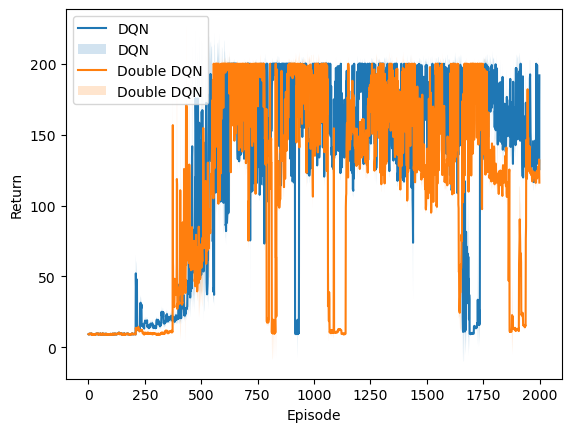

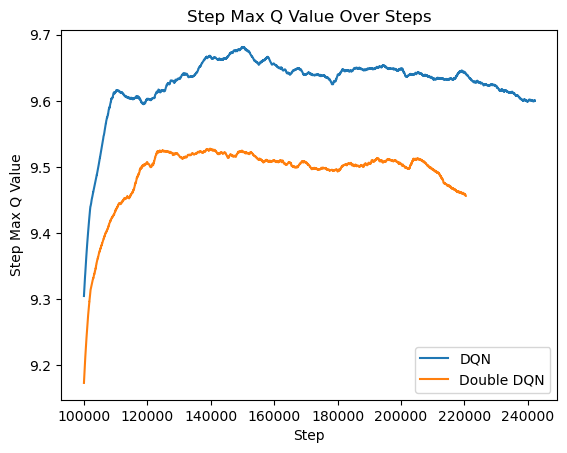

In [9]:
""" Plot the episode rewards"""
# DQN
DQN_Manager.eval_rewards = np.array(DQN_Manager.eval_rewards)
Double_DQN_Manager.eval_rewards = np.array(Double_DQN_Manager.eval_rewards)
dqn_means = np.mean(DQN_Manager.eval_rewards,axis=-1)
dqn_stds = np.std(DQN_Manager.eval_rewards,axis=-1)
ddqn_means = np.mean(Double_DQN_Manager.eval_rewards,axis=-1)
ddqn_stds = np.std(Double_DQN_Manager.eval_rewards,axis=-1)
plt.figure()
plt.plot(dqn_means,label="DQN")
plt.fill_between(np.arange(len(dqn_means)),dqn_means-dqn_stds,dqn_means+dqn_stds,alpha=0.2,label="DQN")
plt.plot(ddqn_means,label="Double DQN")
plt.fill_between(np.arange(len(ddqn_means)),ddqn_means-ddqn_stds,ddqn_means+ddqn_stds,alpha=0.2,label="Double DQN")
plt.xlabel("Episode")
plt.ylabel("Return")
plt.legend()
plt.show()   

import pandas as pd        
""" Plot the max Q value over steps. """
smoothing_window_maxQ = 100000
plt.figure()
maxQ_DQN_smoothed = pd.Series(maxQ_DQN).rolling(smoothing_window_maxQ, min_periods=smoothing_window_maxQ).mean() # smoothing_window = 100000
maxQ_DDQN_smoothed = pd.Series(maxQ_DDQN).rolling(smoothing_window_maxQ, min_periods=smoothing_window_maxQ).mean()
plt.plot(maxQ_DQN_smoothed,label="DQN")
plt.plot(maxQ_DDQN_smoothed,label="Double DQN")
plt.xlabel('Step')
plt.ylabel('Step Max Q Value')
plt.title("Step Max Q Value Over Steps")
plt.legend()
plt.show()